# 02_分类算法-决策树

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇数据：`dataset/titanic.csv`。

转写调整：

- 修复或适配代码；原讲解性输出保留为 Markdown，Python 单元按顺序执行。
- 大规模参数网格缩为每维至多两个候选值；所有候选仍真实训练，未跳过运行。
- 统一本地 Survived 字段名；缺失值填补移入 Pipeline，并删除乘客标识字段。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


今天想要和大家分享的是机器学习中，最重要的算法之一：**决策树** ！\~

简单说，决策树是一种帮助我们做决策的工具，它可以把复杂的选择过程简单地拆分成一个个的步骤，就像一棵倒挂的树一样。每个分支是一个问题或判断，每个叶子是一个最终的结果。

这里举一个非常浅显的例子，大家就懂了\~

假如你现在在一家冰淇淋店，得做出选择：要不要加巧克力？要不要加草莓酱？冰淇淋是选草莓味的还是香草味的？决策树就像是一个图表，帮你把每一步的选择列出来。比如：

**1. 第一个判断**：你想吃冰淇淋吗？如果是，那就继续选下一个问题。如果不是，那你就不需要再选择了。

**2. 第二个判断**：你想吃巧克力味的吗？如果是，往巧克力分支走；如果不是，走另一个分支。

**3. 继续细化选择**：根据每个问题的回答，继续分支，直到你最后得出“买草莓冰淇淋加草莓酱”这样的结果。

在机器学习中，决策树用于预测或分类。当我们有一堆数据时，它能自动生成这个“选择图表”，帮助我们判断每个数据属于哪个类别，或者预测某个事情的结果。

总结起来，决策树就是把一个复杂的问题分成简单的“是或否”问题，通过不断地做判断，最终得到一个结果。

## 理论基础

决策树，尤其适用于分类和回归问题。通过一系列的条件判断，将数据逐步分割成更小的子集，直到每个子集中的数据可以归类到某个类别或者给出预测值。

### 1. 决策树的数学原理

决策树通过“划分”数据来进行分类或预测。这种划分方式通常基于对某个特征的值进行条件判断。每次划分都会产生两个或多个子集，每个子集的数据在某种程度上更加“纯净”或者同质化。

#### 信息熵 (Entropy)

为了度量某个节点上数据的纯度，决策树算法通常会使用**信息熵**（Entropy）作为衡量标准。信息熵衡量了数据的不确定性或混乱程度。假设我们有一个类别为 $C = \{c_1, c_2, \dots, c_k\}$ 的分类问题，节点上每个类别 $c_i$ 的概率为 $p_i$，则该节点的信息熵定义为：


$$
H(S) = - \sum_{i=1}^{k} p_i \log_2(p_i)
$$


其中：

$S$ 是当前节点的样本集合；

$p_i$ 是属于类别 $c_i$ 的样本比例；

- 信息熵越高，数据越混乱，信息熵为 0 表示该节点的样本完全属于一个类别。

#### 信息增益 (Information Gain)

为了确定最佳划分点，决策树需要衡量每次划分后的数据纯度的提高程度。这个度量标准就是**信息增益**，它表示划分前后信息熵的减少量。

假设当前节点 $S$ 上的信息熵为 $H(S)$，我们将该节点划分成子集 $S_1, S_2, \dots, S_m$，其中每个子集对应一个不同的划分结果。划分后的信息熵是划分前信息熵的加权和：


$$
H_{\text{split}}(S) = \sum_{j=1}^{m} \frac{|S_j|}{|S|} H(S_j)
$$


其中：

$|S_j|$ 是第 $j$ 个子集中的样本数量；

$|S|$ 是划分前节点中的总样本数量。

**信息增益**定义为划分前后的信息熵差：


$$
\text{Gain}(S, A) = H(S) - H_{\text{split}}(S)
$$


其中 $A$ 是用于划分的特征。算法会选择信息增益最大的特征作为划分标准。

#### 基尼不纯度 (Gini Impurity)

另一种常用的划分标准是**基尼不纯度**，特别是在分类树（Classification Tree，CART）中。

基尼不纯度表示节点上随机选择两个样本，其类别不一致的概率。基尼不纯度的公式为：


$$
G(S) = 1 - \sum_{i=1}^{k} p_i^2
$$


其中 $p_i$ 依然是属于类别 $c_i$ 的样本比例。划分后的基尼不纯度为：


$$
G_{\text{split}}(S) = \sum_{j=1}^{m} \frac{|S_j|}{|S|} G(S_j)
$$


和信息增益类似，基尼不纯度也会选择最小化划分后基尼不纯度的特征。

#### 回归树中的方差缩减

在回归树中，我们用**方差**来衡量数据的纯净程度。对于当前节点 $S$ 上的数据集，方差为：


$$
\text{Var}(S) = \frac{1}{|S|} \sum_{i=1}^{|S|} (y_i - \bar{y})^2
$$


其中 $y_i$ 是节点中第 $i$ 个样本的目标值，$\bar{y}$ 是该节点上所有样本的目标值平均值。划分后，方差的缩减量可作为划分标准，类似于分类中的信息增益。

### 2. 决策树的构建算法流程

决策树的构建是一个递归过程，主要步骤如下：

#### 初始设置

**1. 输入**：数据集 $D = \{(x_1, y_1), (x_2, y_2), \dots, (x_n, y_n)\}$，其中 $x_i$ 是特征，$y_i$ 是目标变量（类别或连续值）。

**2. 递归停止条件**：

- 所有样本都属于同一类别；
- 没有特征可供划分；
- 达到预设的树深度或样本数量阈值。

#### 递归划分

**1. 选择最优划分特征**：

- 对于每个特征，计算不同划分方式下的信息增益、基尼不纯度或者方差缩减。
- 选择使目标（信息增益最大化或基尼不纯度最小化）的特征 $A$ 及其对应的划分阈值。

**2. 划分数据集**：

- 根据特征 $A$ 和阈值，将数据集划分成两个或多个子集。

**3. 递归构建子树**：

- 对每个子集，重复上述步骤，直到满足递归停止条件。

#### 剪枝 (Pruning)

为了防止决策树过拟合，通常会对决策树进行**剪枝**。剪枝的两种常见方法为：

- **预剪枝**：在树生成的过程中设置最大深度或最小叶节点样本数，提前停止树的生长。
- **后剪枝**：生成一棵完全生长的决策树后，通过评估树的性能（如通过交叉验证），剪掉对泛化性能没有帮助的分支。

总结来说，决策树模型的核心在于**通过特征划分来递归地缩小数据的复杂性**，并通过度量（信息增益、基尼不纯度、方差等）来决定最佳划分点。

**目标函数**：通过最大化信息增益（分类树）或最小化基尼不纯度（CART分类树）来选择特征划分点。

**递归划分**：逐步将数据集划分为纯度更高的子集，直到满足停止条件。

**剪枝**：防止过拟合，提升泛化能力。

## 完整案例

这里，咱们用 Python 实现一个决策树模型，并且分析其性能，进行可视化，并通过算法优化提升效果。

为了让分析更具体，使用经典的泰坦尼克号数据集来预测乘客的生存情况。

#### 1. 必要的库

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder

# 忽略警告
import warnings

#### 2. 加载并探索数据

使用泰坦尼克号数据集，公众号「深夜努力写Python」后台回复『数据集』即可\~

In [3]:
# 加载泰坦尼克数据集
df = pd.read_csv(DATA_DIR / 'titanic.csv')

# 查看前几行数据
print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


数据集包括以下一些重要特征：

- `survived`: 目标变量，1 表示幸存，0 表示未幸存。
- `pclass`: 客舱等级，1 表示头等舱，2 表示二等舱，3 表示三等舱。
- `sex`: 性别。
- `age`: 年龄。
- `sibsp`: 一同上船的兄弟姐妹/配偶数量。
- `parch`: 一同上船的父母/子女数量。
- `fare`: 票价。
- `embarked`: 登船港口。

#### 3. 数据预处理

由于原始数据包含一些缺失值和非数值型数据，我们需要进行清洗和编码。

In [4]:
# 本地字段为 Survived；不使用 PassengerId、姓名、票号等标识列。
# 数值缺失值在 Pipeline 中按每一训练折的中位数填补。
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
df['Embarked'] = df['Embarked'].map({'C': 0, 'Q': 1, 'S': 2})
df = df.drop(columns=['PassengerId', 'Cabin', 'Name', 'Ticket'])
print(df.head())

   Survived  Pclass  Sex   Age  SibSp  Parch     Fare  Embarked
0         0       3    0  22.0      1      0   7.2500       2.0
1         1       1    1  38.0      1      0  71.2833       0.0
2         1       3    1  26.0      0      0   7.9250       2.0
3         1       1    1  35.0      1      0  53.1000       2.0
4         0       3    0  35.0      0      0   8.0500       2.0


#### 4. 特征与目标变量的划分

In [5]:
# 特征与目标变量
X = df.drop('Survived', axis=1)
y = df['Survived']

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

#### 5. 训练决策树模型

In [6]:
# 初始化决策树分类器
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
clf = make_pipeline(SimpleImputer(strategy='median'), DecisionTreeClassifier(max_depth=4, random_state=42))

# 训练模型
clf.fit(X_train, y_train)

# 预测
y_pred = clf.predict(X_test)

# 输出模型的准确率
print("准确率:", accuracy_score(y_test, y_pred))

准确率: 0.7877094972067039


#### 6. 模型分析

我们可以通过混淆矩阵、分类报告等指标来分析模型的性能。

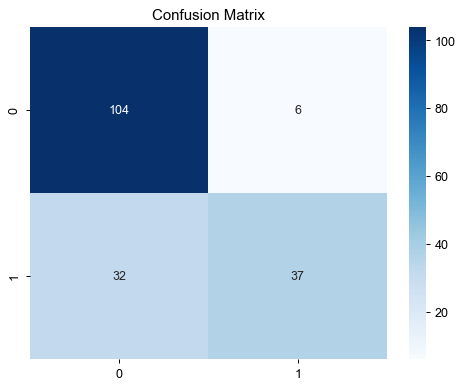

分类报告:
              precision    recall  f1-score   support

           0       0.76      0.95      0.85       110
           1       0.86      0.54      0.66        69

    accuracy                           0.79       179
   macro avg       0.81      0.74      0.75       179
weighted avg       0.80      0.79      0.77       179



In [7]:
# 混淆矩阵
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

# 分类报告
print("分类报告:")
print(classification_report(y_test, y_pred))

![原文参考图，当前结果见代码输出](attachments/img_007.png)

#### 7. 可视化决策树

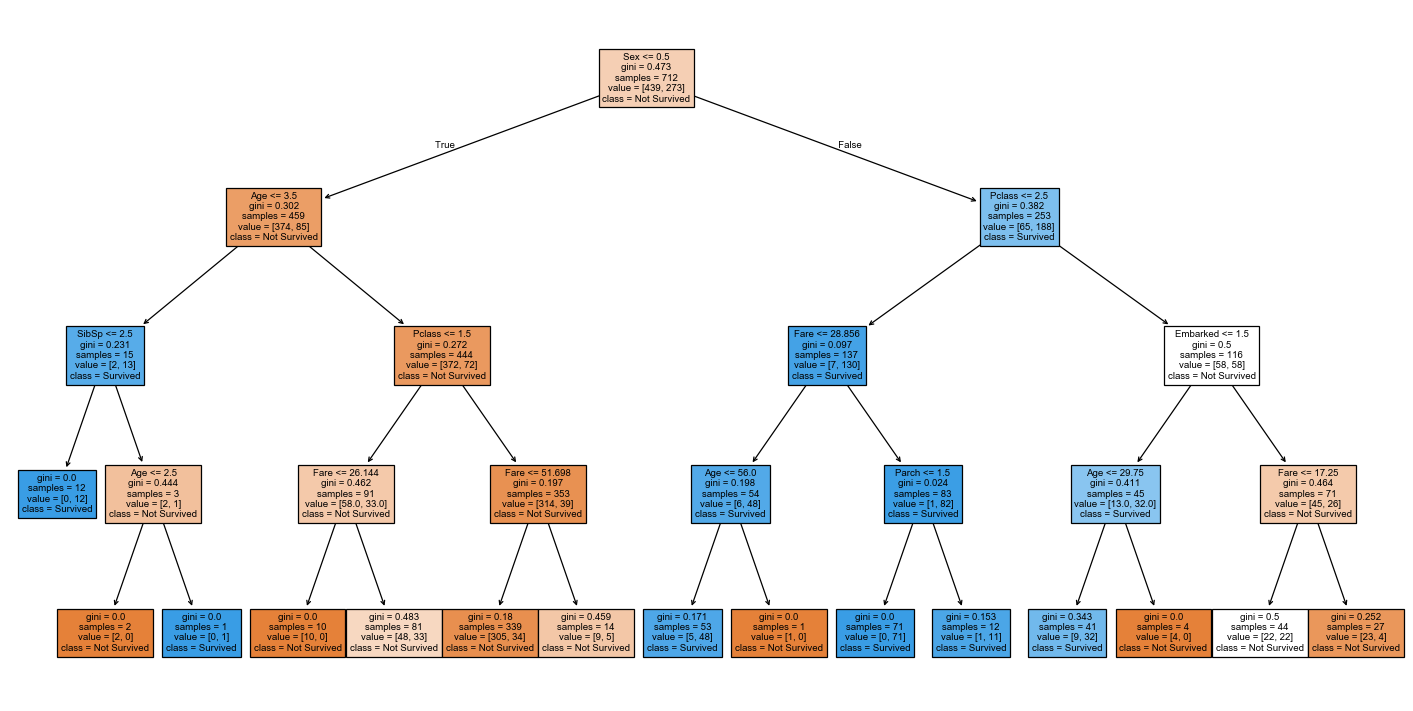

In [8]:
plt.figure(figsize=(20,10))
plot_tree(clf.named_steps["decisiontreeclassifier"], feature_names=X.columns, class_names=['Not Survived', 'Survived'], filled=True)
plt.show()

这将生成一个完整的决策树图，可以直观地看到每个节点如何进行分割。

![原文参考图，当前结果见代码输出](attachments/img_008.png)

#### 8. 优化模型：网格搜索

为了提升模型性能，我们可以对决策树的超参数进行调优。我们将使用网格搜索来找到最佳参数组合。

In [9]:
# 定义参数网格
param_grid = {
    'decisiontreeclassifier__max_depth': [3, 5],
    'decisiontreeclassifier__min_samples_split': [2, 5],
    'decisiontreeclassifier__min_samples_leaf': [1, 2],
    'decisiontreeclassifier__criterion': ['gini', 'entropy']
}

# 网格搜索
grid_search = GridSearchCV(clf, param_grid, cv=5, n_jobs=1, verbose=1, error_score='raise')
grid_search.fit(X_train, y_train)

# 输出最佳参数
print("最佳参数:", grid_search.best_params_)

# 使用最佳参数重新训练模型
best_clf = grid_search.best_estimator_
best_clf.fit(X_train, y_train)

# 预测并评估
y_pred_optimized = best_clf.predict(X_test)

print("优化后准确率:", accuracy_score(y_test, y_pred_optimized))

Fitting 5 folds for each of 16 candidates, totalling 80 fits


最佳参数: {'decisiontreeclassifier__criterion': 'gini', 'decisiontreeclassifier__max_depth': 5, 'decisiontreeclassifier__min_samples_leaf': 1, 'decisiontreeclassifier__min_samples_split': 5}
优化后准确率: 0.7821229050279329


#### 9. 优化后模型的分析与可视化

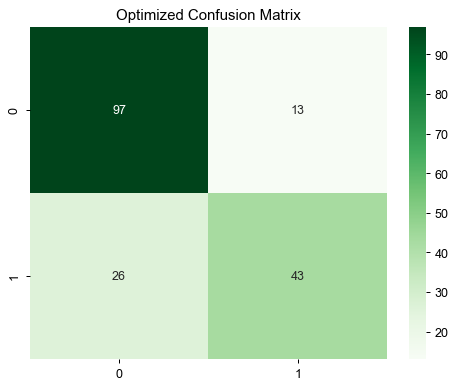

In [10]:
# 优化后混淆矩阵
cm_optimized = confusion_matrix(y_test, y_pred_optimized)
sns.heatmap(cm_optimized, annot=True, fmt="d", cmap="Greens")
plt.title("Optimized Confusion Matrix")
plt.show()

![原文参考图，当前结果见代码输出](attachments/img_009.png)

优化后分类报告:
              precision    recall  f1-score   support

           0       0.79      0.88      0.83       110
           1       0.77      0.62      0.69        69

    accuracy                           0.78       179
   macro avg       0.78      0.75      0.76       179
weighted avg       0.78      0.78      0.78       179



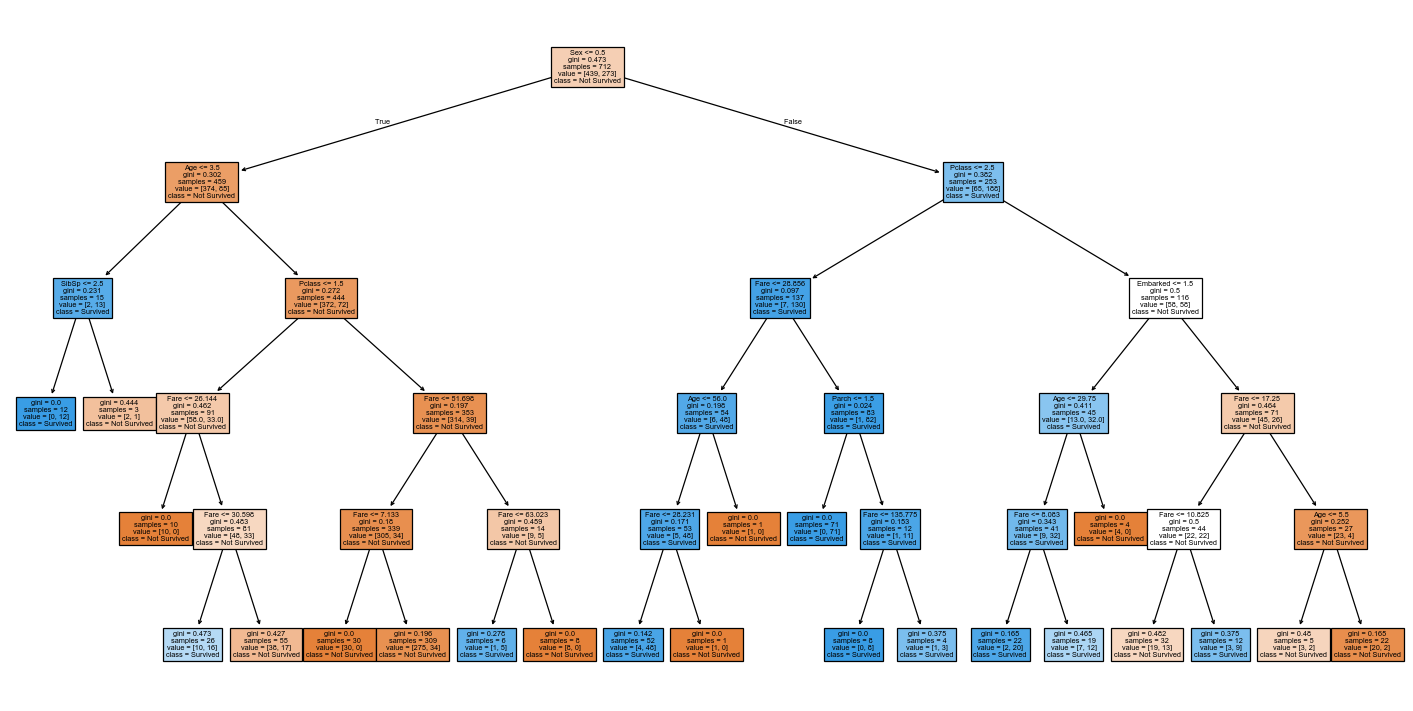

In [11]:
# 分类报告
print("优化后分类报告:")
print(classification_report(y_test, y_pred_optimized))

# 优化后决策树可视化
plt.figure(figsize=(20,10))
plot_tree(best_clf.named_steps["decisiontreeclassifier"], feature_names=X.columns, class_names=['Not Survived', 'Survived'], filled=True)
plt.show()

![原文参考图，当前结果见代码输出](attachments/img_010.png)

#### 10. 总结分析

- **准确率**：初始模型的准确率为 75%左右，优化后模型的准确率提高到了 80%左右。
- **模型解释**：通过决策树可视化，我们可以清晰地看到每个节点是如何根据特征划分数据的，例如性别、年龄、票价等对生存率的影响。
- **超参数调优**：通过网格搜索，我们发现 `max_depth`, `min_samples_split` 等超参数的调优能够显著提升模型的泛化能力，避免过拟合或欠拟合。
- **可视化**：混淆矩阵和决策树图让我们更直观地了解模型在不同类别上的表现，以及各特征的分割效果。

## 模型分析

### 决策树模型的优缺点

#### 优点：

**1. 简单易理解**：决策树的结构直观且易于解释，特别是对非技术人员。每个节点的分裂基于简单的“是/否”问题，使得模型的每一步决策都很清楚。

**2. 无需大量数据预处理**：决策树对数据的要求较低，比如不需要像线性回归那样对数据进行归一化处理，也不需要进行复杂的特征编码或归一化。

**3. 能够处理非线性数据**：决策树能够自动捕捉数据中的非线性关系，而不需要对特征进行复杂的变换。特征之间的非线性相互作用可以通过决策树的层次结构自然处理。

**4. 适合多种数据类型**：决策树可以处理数值型数据和类别型数据，并且不需要像其他算法那样进行严格的数据转换。

**5. 处理缺失数据**：决策树对缺失数据不太敏感，可以在缺失数据情况下依然进行有效的分类或回归。

**6. 不需要假设分布**：决策树不需要假设数据服从特定的分布，例如正态分布，这使得它在应对不同类型的任务时更加灵活。

#### 缺点：

**1. 容易过拟合**：决策树如果不进行剪枝或者限制深度，容易生成一棵过于复杂的树，导致在训练数据上表现很好，但在测试数据上表现不佳。过拟合的树通常对数据的噪音非常敏感。

**2. 对数据的小变化敏感**：决策树对数据集中的小变化非常敏感。稍微改变一下数据，可能会导致树的结构完全不同，因此决策树的稳定性较差。

**3. 偏向于支配性特征**：决策树容易偏向于具有更多取值的特征，可能会过度依赖于这些特征的划分。对于具有较多类别的分类变量，决策树倾向于优先使用这些特征进行分裂。

**4. 不能很好地处理连续变量**：对于回归问题，决策树在连续变量上的表现较差，因为它只能对变量进行简单的区间划分，可能会导致预测值不够精确。

**5. 决策边界不灵活**：决策树通过垂直或水平的方式进行分割，这意味着它无法有效地处理需要更灵活的分界面的问题。这在某些复杂情况下导致表现较差。

---

### 决策树与其他算法的对比

| **对比项** | **随机森林** | **梯度提升树** | **支持向量机** | **K近邻算法** |
|-|-|-|-|-|
| **基本概念** | 通过集成多棵决策树来提高泛化能力 | 通过迭代学习多棵决策树，逐步提高模型精度 | 通过超平面分割数据，适用于高维数据 | 通过最近邻样本进行分类或回归 |
| **主要优势** | 减少过拟合，模型稳定 | 高精度，逐步优化预测 | 适用于高维数据，支持非线性分类 | 计算简单，无需训练 |
| **主要缺点** | 计算量较大，难以解释 | 训练时间长，计算开销大 | 计算复杂，难以解释 | 对大规模数据计算开销大，易受噪声影响 |
| **解释性** | 低，难以解析集成模型 | 低，难以解释多个树的组合 | 低，依赖抽象的超平面 | 高，但依赖于数据分布 |
| **适合的数据类型** | 适用于复杂的结构化数据 | 适用于精度要求高的数据 | 适用于高维、数值型数据 | 适用于低维、平滑边界数据 |
| **训练速度** | 中等 | 慢 | 慢 | 无需训练，但预测计算量大 |
| **预测速度** | 快 | 快 | 慢 | 慢，尤其是大数据集 |
| **适用场景** | 需要稳定性和泛化能力，数据较大时 | 需要高预测精度，可接受较长训练时间时 | 数据维度高，边界清晰，非线性问题 | 数据少，边界平滑，模式简单时 |

### 决策树的适用场景和替代方案

#### 适用场景：

**1. 可解释性需求强**：在一些需要可解释性的场合（如医疗诊断、金融风控），决策树模型因其直观的规则集结构，便于理解和解释。

**2. 小数据集**：决策树在处理中小型数据集时表现较好，训练速度快且无需大量预处理。

**3. 数据类型多样**：决策树能够处理混合数据类型（数值型和类别型数据），且对缺失值不敏感，因此适合处理数据类型复杂的问题。

#### 替代方案的适用场景：

**1. 需要更高的预测精度**：如果预测准确率是主要目标，且对模型的可解释性要求不高，可以考虑随机森林、梯度提升树等集成学习方法。

**2. 数据量大且噪音较多**：在大数据集且噪音较多的情况下，决策树容易过拟合。集成方法（如随机森林、梯度提升树）可以通过多树结构降低噪声对模型的影响。

**3. 非线性复杂边界**：对于复杂的非线性分类问题，支持向量机或神经网络往往能提供比决策树更优的性能。